# Experiment: Mode Count Sweep

Objective:
- Visualize `M_mm(lambda)` and `eta_match(lambda)` for 3/7/19-port lanterns.
- Inspect how changing `lambda0_nm` moves the matching point.


In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / 'src').exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.config_loader import load_config_bundle
from src.lantern_surrogate import LanternInternalModel
from src.sky_background import sky_photon_flux_per_nm_arcsec2
from src.snr import stacked_snr
from src.system_model import SystemModel

config = load_config_bundle(REPO_ROOT / 'config')
lam_nm = config['lam_nm']
base = config['base']
plt.rcParams['figure.dpi'] = 140


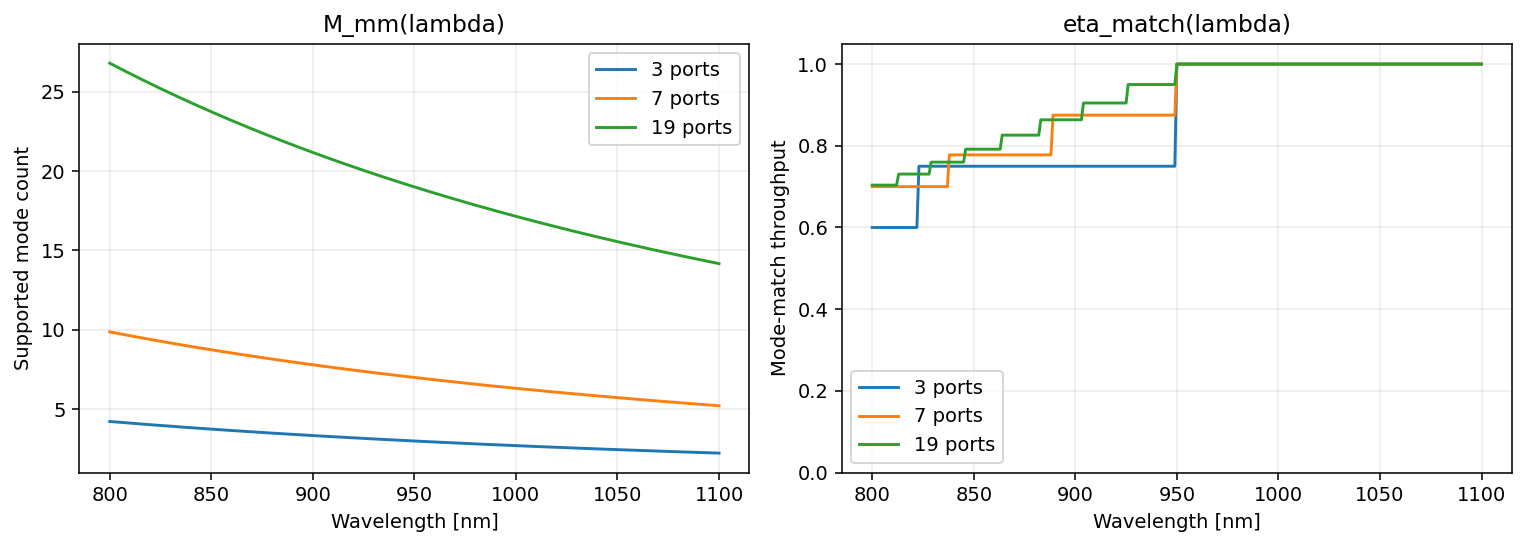

In [2]:
port_list = [3, 7, 19]
models = {
    n_port: LanternInternalModel(
        n_port=n_port,
        lambda0_nm=base['lantern']['lambda0_nm'],
        alpha_ad=base['lantern']['alpha_ad'],
        eta0=base['lantern']['eta0'],
        sigma_mix=base['lantern']['sigma_mix'],
        w_cut=base['lantern']['w_cut'],
    )
    for n_port in port_list
}

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for n_port, model in models.items():
    axes[0].plot(lam_nm, model.mm_mode_count(lam_nm), label=f'{n_port} ports')
    axes[1].plot(lam_nm, model.eta_match(lam_nm), label=f'{n_port} ports')

axes[0].set_xlabel('Wavelength [nm]')
axes[0].set_ylabel('Supported mode count')
axes[0].set_title('M_mm(lambda)')
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].set_xlabel('Wavelength [nm]')
axes[1].set_ylabel('Mode-match throughput')
axes[1].set_ylim(0.0, 1.05)
axes[1].set_title('eta_match(lambda)')
axes[1].grid(alpha=0.25)
axes[1].legend()
plt.tight_layout()


## Lambda0 sensitivity

The surrogate is pinned at `lambda0_nm`, where the modal support is best matched by construction. Sweeping `lambda0_nm` shows how the throughput turnover shifts along the band.


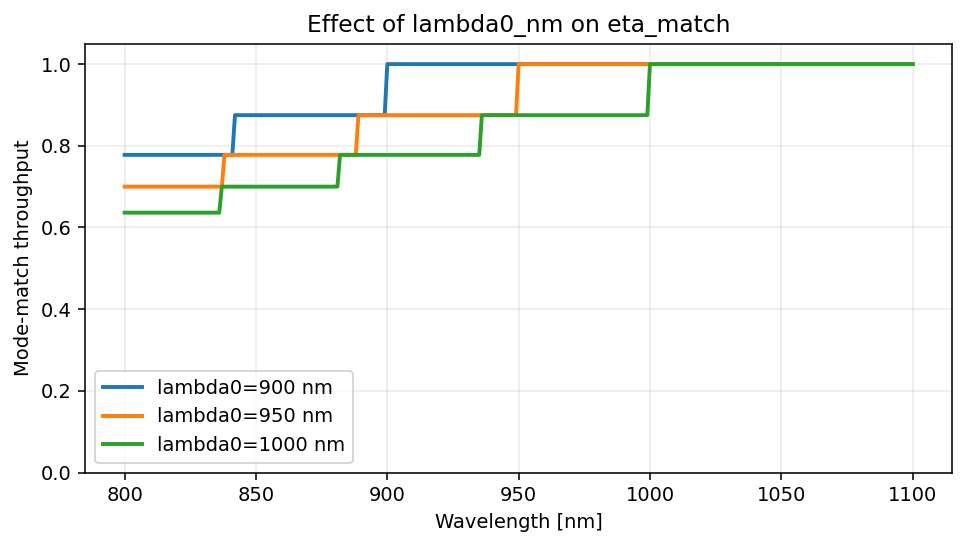

In [3]:
lambda0_candidates = [900.0, 950.0, 1000.0]
fig, ax = plt.subplots(figsize=(7, 4))
for lambda0_nm in lambda0_candidates:
    model = LanternInternalModel(
        n_port=7,
        lambda0_nm=lambda0_nm,
        alpha_ad=base['lantern']['alpha_ad'],
        eta0=base['lantern']['eta0'],
        sigma_mix=base['lantern']['sigma_mix'],
        w_cut=base['lantern']['w_cut'],
    )
    ax.plot(lam_nm, model.eta_match(lam_nm), linewidth=2, label=f'lambda0={lambda0_nm:.0f} nm')

ax.set_xlabel('Wavelength [nm]')
ax.set_ylabel('Mode-match throughput')
ax.set_ylim(0.0, 1.05)
ax.set_title('Effect of lambda0_nm on eta_match')
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
